# MA-BBOB Training Instance Selection

Select 10 training instances from the 1000-instance MA-BBOB pool that give balanced coverage of all 24 BBOB functions and 5 function groups.

In [1]:
import pandas as pd
import numpy as np

In [2]:
weights = pd.read_csv("../BLADE/iohblade/problems/mabbob/weights.csv", index_col=0)
W = weights.values  # 1000 x 24

# BBOB function groups
GROUPS = {
    "Separable (f1-f5)": list(range(0, 5)),
    "Low/mod conditioning (f6-f9)": list(range(5, 9)),
    "High cond / unimodal (f10-f14)": list(range(9, 14)),
    "Multimodal adequate (f15-f19)": list(range(14, 19)),
    "Multimodal weak (f20-f24)": list(range(19, 24)),
}

print(f"Pool: {W.shape[0]} instances, {W.shape[1]} BBOB functions")
print(f"Weights per row sum to: {W.sum(axis=1).mean():.4f} (should be 1.0)")

Pool: 1000 instances, 24 BBOB functions
Weights per row sum to: 1.0000 (should be 1.0)


## Greedy selection

Score function penalises:
1. Missing BBOB functions (heaviest penalty)
2. Uneven group balance (deviation from 20% each)
3. Uneven per-function coverage (coefficient of variation)

In [3]:
def score_subset(indices):
    sub = W[indices]
    func_totals = sub.sum(axis=0)
    total = func_totals.sum()
    if total == 0:
        return -9999
    missing = (func_totals == 0).sum()
    group_shares = [func_totals[cols].sum() / total for cols in GROUPS.values()]
    group_dev = np.std(group_shares)
    nonzero = func_totals[func_totals > 0]
    func_cv = np.std(nonzero) / np.mean(nonzero) if len(nonzero) > 0 else 999
    return -missing * 100 - group_dev * 10 - func_cv


selected = []
remaining = list(range(1000))

for step in range(10):
    best_score = -9999
    best_idx = -1
    for idx in remaining:
        s = score_subset(selected + [idx])
        if s > best_score:
            best_score = s
            best_idx = idx
    selected.append(best_idx)
    remaining.remove(best_idx)
    n_covered = (W[selected].sum(axis=0) > 0).sum()
    print(f"Step {step+1}: added instance {best_idx:>3} "
          f"({n_covered}/24 functions covered, score={best_score:.4f})")

selected.sort()
print(f"\nSelected indices: {selected}")

Step 1: added instance 277 (9/24 functions covered, score=-1501.3639)
Step 2: added instance 760 (16/24 functions covered, score=-801.1884)
Step 3: added instance 744 (21/24 functions covered, score=-300.8501)
Step 4: added instance 191 (24/24 functions covered, score=-0.7854)
Step 5: added instance 843 (24/24 functions covered, score=-0.6148)
Step 6: added instance 300 (24/24 functions covered, score=-0.4841)
Step 7: added instance 412 (24/24 functions covered, score=-0.4924)
Step 8: added instance 648 (24/24 functions covered, score=-0.4122)
Step 9: added instance 635 (24/24 functions covered, score=-0.3567)
Step 10: added instance 455 (24/24 functions covered, score=-0.3410)

Selected indices: [191, 277, 300, 412, 455, 635, 648, 744, 760, 843]


## Per-instance weight breakdown

In [4]:
func_labels = [f"f{i+1}" for i in range(24)]

# Build a styled DataFrame
detail = pd.DataFrame(W[selected], index=selected, columns=func_labels)
detail.index.name = "Instance"

# Replace zeros with NaN for cleaner display
detail_display = detail.replace(0, np.nan)

# Format as percentages
styled = (
    detail_display.style
    .format("{:.1%}", na_rep=".")
    .background_gradient(cmap="YlOrRd", axis=None, vmin=0, vmax=0.3)
)
styled

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24
Instance,,,,,,,,,,,,,,,,,,,,,,,,
191,.,.,.,.,.,27.7%,.,.,.,.,.,.,.,.,.,.,.,.,24.6%,21.3%,1.0%,.,25.4%,.
277,14.8%,.,14.4%,.,.,.,9.9%,.,.,12.5%,.,.,13.3%,5.8%,.,.,.,19.6%,.,.,.,5.8%,.,3.8%
300,.,.,18.6%,.,.,.,20.5%,.,0.4%,.,.,17.9%,.,.,.,.,.,11.6%,.,.,29.3%,.,1.8%,.
412,.,9.8%,.,.,12.5%,.,.,13.2%,.,14.1%,.,.,.,.,.,.,10.8%,.,11.0%,.,.,.,.,28.6%
455,.,12.9%,.,.,.,.,.,16.6%,.,14.4%,13.8%,.,.,.,.,.,.,14.0%,.,.,.,.,.,28.3%
635,.,.,.,22.9%,3.7%,.,12.8%,.,.,.,.,8.8%,.,15.6%,.,22.5%,.,.,.,.,.,13.6%,.,.
648,5.1%,.,.,9.4%,.,.,19.5%,.,17.7%,.,.,.,18.1%,.,17.2%,.,.,.,.,10.5%,2.4%,.,.,.
744,.,17.0%,.,.,.,19.1%,.,.,.,10.1%,.,0.4%,.,6.5%,16.6%,15.1%,15.2%,.,.,.,.,.,.,.
760,.,1.4%,.,9.4%,11.7%,.,.,4.5%,20.4%,.,6.9%,.,15.3%,.,.,.,.,.,.,.,16.6%,13.8%,.,.


## Per-function coverage summary

In [5]:
sub = W[selected]
func_totals = sub.sum(axis=0)
func_counts = (sub > 0).sum(axis=0)
total = func_totals.sum()

func_summary = pd.DataFrame({
    "Function": func_labels,
    "# Instances": func_counts,
    "Weight sum": func_totals,
    "Share": func_totals / total,
}).set_index("Function")

# Add group labels
group_map = {}
for gname, cols in GROUPS.items():
    for c in cols:
        group_map[func_labels[c]] = gname.split(" (")[0]
func_summary["Group"] = func_summary.index.map(group_map)

func_summary.style.format({"Weight sum": "{:.3f}", "Share": "{:.1%}"})

,# Instances,Weight sum,Share,Group
Function,,,,
f1,2,0.199,2.0%,Separable
f2,5,0.621,6.2%,Separable
f3,2,0.329,3.3%,Separable
f4,4,0.560,5.6%,Separable
f5,3,0.280,2.8%,Separable
f6,2,0.468,4.7%,Low/mod conditioning
f7,4,0.627,6.3%,Low/mod conditioning
f8,4,0.488,4.9%,Low/mod conditioning
f9,3,0.385,3.9%,Low/mod conditioning


## Group balance

In [6]:
group_data = []
for gname, cols in GROUPS.items():
    gweight = func_totals[cols].sum()
    group_data.append({
        "Group": gname,
        "Weight sum": gweight,
        "Share": gweight / total,
        "Deviation from 20%": gweight / total - 0.2,
    })

group_df = pd.DataFrame(group_data).set_index("Group")
group_df.style.format({"Weight sum": "{:.3f}", "Share": "{:.1%}", "Deviation from 20%": "{:+.1%}"})

,Weight sum,Share,Deviation from 20%
Group,,,
Separable (f1-f5),1.989,19.9%,-0.1%
Low/mod conditioning (f6-f9),1.968,19.7%,-0.3%
High cond / unimodal (f10-f14),2.061,20.6%,+0.6%
Multimodal adequate (f15-f19),1.959,19.6%,-0.4%
Multimodal weak (f20-f24),2.023,20.2%,+0.2%


## Comparison with old selection (indices 0-9)

In [7]:
old_indices = list(range(10))
old_sub = W[old_indices]
old_totals = old_sub.sum(axis=0)
old_total = old_totals.sum()

comparison = []
for gname, cols in GROUPS.items():
    old_share = old_totals[cols].sum() / old_total
    new_share = func_totals[cols].sum() / total
    comparison.append({
        "Group": gname,
        "Old (0-9)": old_share,
        "New (selected)": new_share,
        "Ideal": 0.2,
    })

comp_df = pd.DataFrame(comparison).set_index("Group")

old_missing = [f"f{i+1}" for i in range(24) if old_totals[i] == 0]
new_missing = [f"f{i+1}" for i in range(24) if func_totals[i] == 0]

print(f"Old missing functions: {old_missing if old_missing else 'NONE'}")
print(f"New missing functions: {new_missing if new_missing else 'NONE'}")
print()
comp_df.style.format("{:.1%}")

Old missing functions: ['f4', 'f5', 'f15', 'f18', 'f20', 'f22']
New missing functions: NONE



,Old (0-9),New (selected),Ideal
Group,,,
Separable (f1-f5),12.5%,19.9%,20.0%
Low/mod conditioning (f6-f9),20.1%,19.7%,20.0%
High cond / unimodal (f10-f14),21.1%,20.6%,20.0%
Multimodal adequate (f15-f19),16.8%,19.6%,20.0%
Multimodal weak (f20-f24),29.4%,20.2%,20.0%


## Per-function weight distribution

How evenly is each BBOB function's total weight distributed across the selected instances? The ideal share per function is 1/24 = 4.2%.

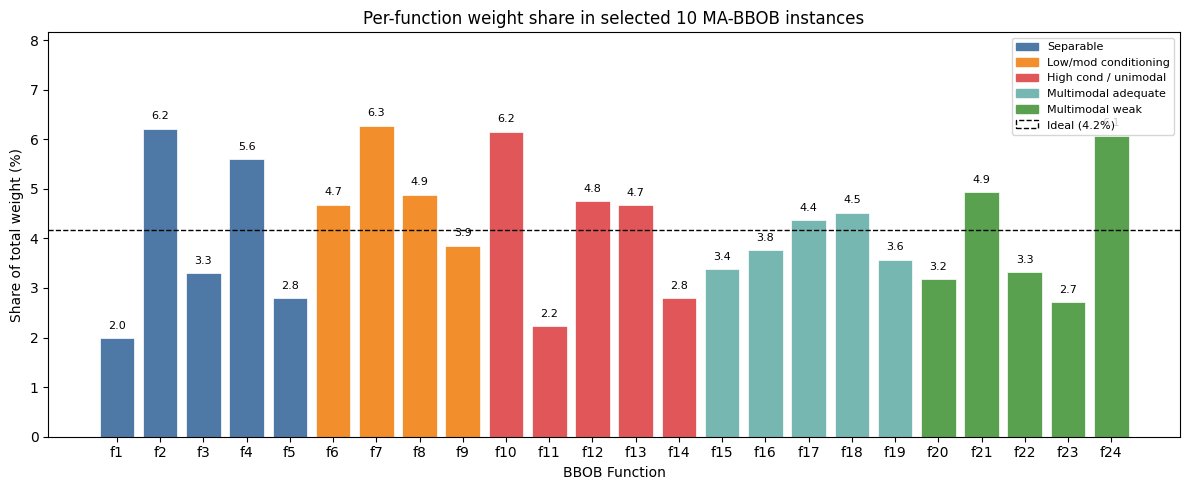

Per-function share: min=2.0%, max=6.3%, mean=4.2%, std=1.3%
Coefficient of variation: 0.30 (0 = perfectly uniform)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ideal = 1.0 / 24
shares = func_totals / total

# Colour by group
group_colors = {
    "Separable": "#4e79a7",
    "Low/mod conditioning": "#f28e2b",
    "High cond / unimodal": "#e15759",
    "Multimodal adequate": "#76b7b2",
    "Multimodal weak": "#59a14f",
}
bar_colors = [group_colors[group_map[f]] for f in func_labels]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(func_labels, shares * 100, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axhline(y=ideal * 100, color="black", linestyle="--", linewidth=1, label=f"Ideal ({ideal*100:.1f}%)")
ax.set_ylabel("Share of total weight (%)")
ax.set_xlabel("BBOB Function")
ax.set_title("Per-function weight share in selected 10 MA-BBOB instances")
ax.set_ylim(0, max(shares * 100) * 1.3)

# Annotate each bar
for bar, share in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{share*100:.1f}", ha="center", va="bottom", fontsize=8)

# Legend for groups
patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
patches.append(mpatches.Patch(facecolor="none", edgecolor="black", linestyle="--", label="Ideal (4.2%)"))
ax.legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"Per-function share: min={shares.min()*100:.1f}%, max={shares.max()*100:.1f}%, "
      f"mean={shares.mean()*100:.1f}%, std={shares.std()*100:.1f}%")
print(f"Coefficient of variation: {shares.std()/shares.mean():.2f} (0 = perfectly uniform)")

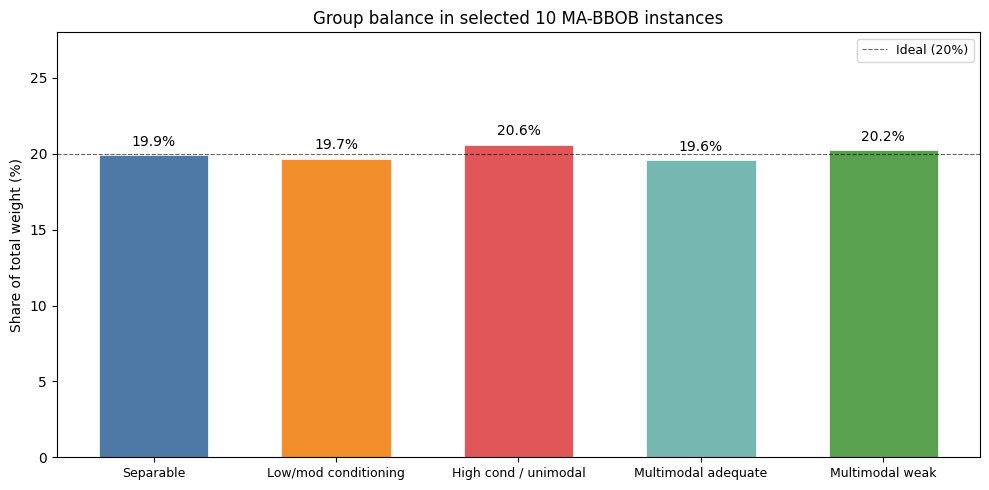

In [13]:
group_names_short = [g.split(" (")[0] for g in GROUPS.keys()]
group_cols_list = list(GROUPS.values())
group_shares_new = [func_totals[cols].sum() / total for cols in group_cols_list]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(group_names_short))
colors = list(group_colors.values())

bars = ax.bar(x, [s * 100 for s in group_shares_new], color=colors,
              edgecolor="white", linewidth=0.5, width=0.6)
ax.axhline(y=20, color="black", linestyle="--", linewidth=0.8, alpha=0.6, label="Ideal (20%)")

ax.set_ylabel("Share of total weight (%)")
ax.set_xticks(x)
ax.set_xticklabels(group_names_short, fontsize=9)
ax.set_title("Group balance in selected 10 MA-BBOB instances")
ax.set_ylim(0, 28)

for bar, share in zip(bars, group_shares_new):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{share*100:.1f}%", ha="center", va="bottom", fontsize=10)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-function comparison: Old vs New vs Full pool

/var/folders/jr/n9z3k78146x3z51srj3w4g3c0000gn/T/ipykernel_92242/740290388.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#d4d4d4", edgecolor="grey", label="Old (0-9)"),


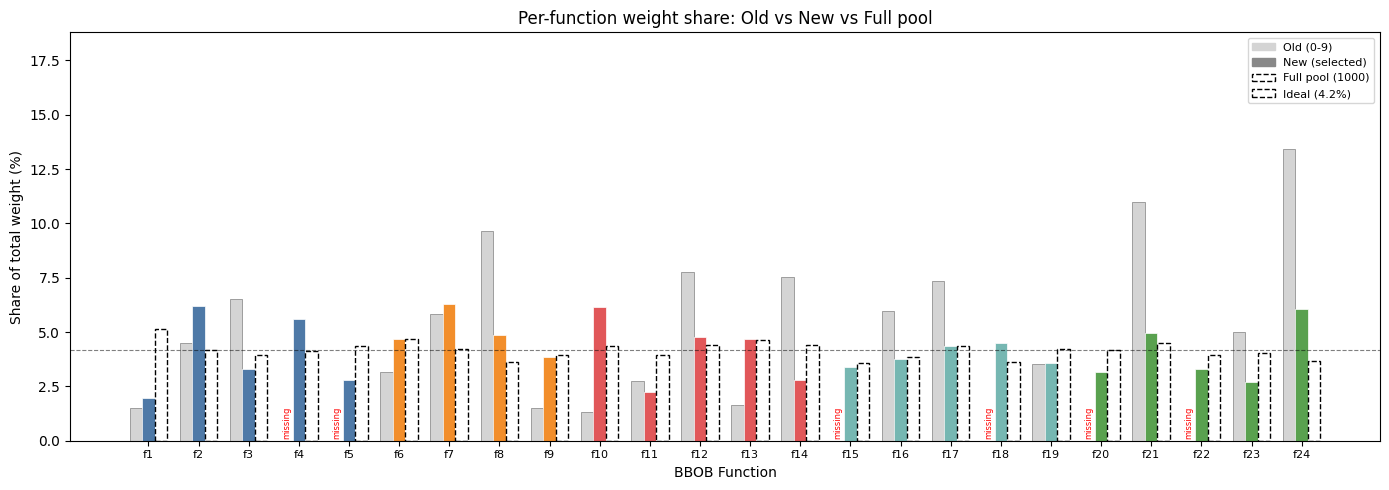

       Old CV   New CV  Pool CV
         0.61     0.30     0.09

CV = coefficient of variation (lower = more uniform)


In [10]:
old_shares = old_totals / old_total
new_shares = func_totals / total
pool_totals = W.sum(axis=0)
pool_shares = pool_totals / pool_totals.sum()

x = np.arange(24)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))

bars_old = ax.bar(x - width, old_shares * 100, width,
                  label="Old (0-9)", color="#d4d4d4", edgecolor="grey", linewidth=0.5)
bars_new = ax.bar(x, new_shares * 100, width,
                  label="New (selected)", color=bar_colors, edgecolor="white", linewidth=0.5)
bars_pool = ax.bar(x + width, pool_shares * 100, width,
                   label="Full pool (1000)", color="white",
                   edgecolor="black", linewidth=1, linestyle="--")

ax.axhline(y=ideal * 100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Share of total weight (%)")
ax.set_xlabel("BBOB Function")
ax.set_xticks(x)
ax.set_xticklabels(func_labels, fontsize=8)
ax.set_title("Per-function weight share: Old vs New vs Full pool")
ax.set_ylim(0, max(old_shares.max(), new_shares.max(), pool_shares.max()) * 100 * 1.4)

# Mark missing functions in old selection
for i in range(24):
    if old_totals[i] == 0:
        ax.annotate("missing", (x[i] - width, 0.15), fontsize=6, color="red",
                    ha="center", rotation=90)

patches = [
    mpatches.Patch(color="#d4d4d4", edgecolor="grey", label="Old (0-9)"),
    mpatches.Patch(color="#888888", label="New (selected)"),
    mpatches.Patch(facecolor="white", edgecolor="black", linestyle="--", label="Full pool (1000)"),
    mpatches.Patch(facecolor="none", edgecolor="black", linestyle="--", label=f"Ideal ({ideal*100:.1f}%)"),
]
ax.legend(handles=patches, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Summary comparison
print(f"{'':>4} {'Old CV':>8} {'New CV':>8} {'Pool CV':>8}")
print(f"{'':>4} {old_shares[old_shares>0].std()/old_shares[old_shares>0].mean():>8.2f}"
      f" {new_shares.std()/new_shares.mean():>8.2f}"
      f" {pool_shares.std()/pool_shares.mean():>8.2f}")
print(f"\nCV = coefficient of variation (lower = more uniform)")

## Group comparison: Old vs New vs Full pool

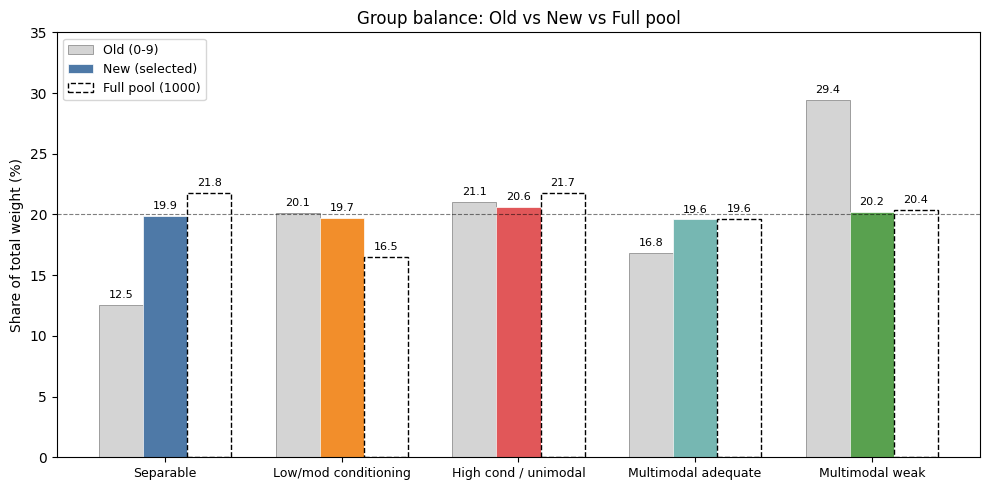

In [12]:
group_shares_old = [old_totals[cols].sum() / old_total for cols in group_cols_list]
group_shares_pool = [W[:, cols].sum() / W.sum() for cols in group_cols_list]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(group_names_short))
width = 0.25

bars_old = ax.bar(x - width, [s * 100 for s in group_shares_old],
                  width, label="Old (0-9)", color="#d4d4d4", edgecolor="grey", linewidth=0.5)
bars_new = ax.bar(x, [s * 100 for s in group_shares_new],
                  width, label="New (selected)", color=colors,
                  edgecolor="white", linewidth=0.5)
bars_pool = ax.bar(x + width, [s * 100 for s in group_shares_pool],
                   width, label="Full pool (1000)", color="white",
                   edgecolor="black", linewidth=1, linestyle="--")

ax.axhline(y=20, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Share of total weight (%)")
ax.set_xticks(x)
ax.set_xticklabels(group_names_short, fontsize=9)
ax.set_title("Group balance: Old vs New vs Full pool")
ax.set_ylim(0, 35)

for barset in [bars_old, bars_new, bars_pool]:
    for bar in barset:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                f"{h:.1f}", ha="center", va="bottom", fontsize=8)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()